# The Enzymatic System
## Mass Action Kinetics

Here is a simple conceptual model of an enzymatically catalysed reaction. It involves these molecular species: a substrate $S$; the product $P$, an enzyme $E$ and the enzyme-substrate complex $ES$. 
We describe the biochemical reactions going with specifying the reactants and the products of each interaction between the species:

$$E + S \xrightarrow{k_1} ES$$
$$ES \xrightarrow{k_{-1}} E + S$$
$$ES \xrightarrow{k_1} E + P$$

with the rate constants denoted by $k_1$, $k_{-1}$ and $k_2$ respectively.
Here each arrow shows the direction of a reaction, the constant above it indicates that in a given situation the reaction happens with a speed specified by that constant.

The scheme summarises that substrate and enzyme combine to form the enzyme-substrate complex. The enzyme substrate complex dissolves back into substrate and enzyme. And the enzyme substrate complex dissolves to release enzyme and product. The first two reactions describe an equilibrium between substrate and enzyme. The third reaction is the critical step that converts substrate to product and releases the enzyme. 

We have four species which means that we have to write down four differential equations to simulate the model numerically. The rate of a reaction (the right-hand side of the differential equation) is given by the product of the reactants times the rate constant. E.g. in mathematical notation the rate of the first reaction is:

$$ \frac{dS}{dt}  = -k_1 \cdot E \cdot S $$
$$ \frac{dE}{dt}  = -k_1 \cdot E \cdot S $$

The negative sign indicates that the species are consumed, a positive sign shows that the species is produced. 

If a species participates in more thabn one reaction, the respective rates are added up.

Following this rule we arrive at the following system of differential equations for our three reactions:
$$ \frac{dS}{dt}  = -k_1 \cdot E \cdot S + k_{-1} \cdot ES$$
$$ \frac{dE}{dt}  = -k_1 \cdot E \cdot S + k_{-1} \cdot ES + k_2 \cdot ES$$
$$ \frac{dES}{dt} = +k_1 \cdot E \cdot S - k_{-1} \cdot ES - k_2 \cdot ES$$
$$ \frac{dP}{dt}  = +k_2 \cdot ES$$

The critical step is to now take these equations and convert them to a Python model function for numerical integration. Here is the function:


In [1]:
def enzyme_kinetic_model(variables, time, parameters):
    
    S, E, ES, P = variables[0], variables[1], variables[2], variables[3]
    
    k1, km1, k2 = parameters[0], parameters[1], parameters[2]
    
    dS_dt  = - k1*E*S + km1*ES
    dE_dt  = - k1*E*S + km1*ES + k2*ES
    dES_dt = + k1*E*S - km1*ES - k2*ES
    dP_dt  =                   + k2*ES
    
    return [dS_dt, dE_dt, dES_dt, dP_dt]


Here the four variables represent the concentration of each species. 
For each species, we have added together the rates of all reactions in which it is involved. 
Each reaction has a rate constant with it. 
Plus means production, minus degradation. The notation orders the terms according to reactions as you can see from the rate constants.  A term that multiplies one concentration with a rate constant is called linear. The binding of substrate to enzyme (reaction 1) is nonlinear because two concentrations are multiplied with each other.


## Simulation of the Closed Model

The code below integrates our model using the ```odeint``` function. This is analagous to the way we integrated the harmonic oscillator equations – only now we have four variables ($E, \, S, \, ES, \, P$).

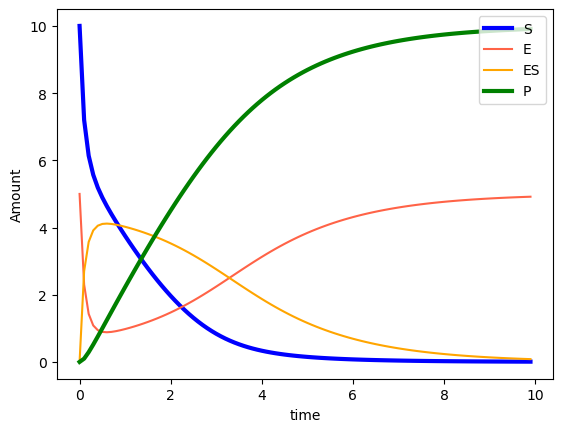

In [40]:
from scipy.integrate import odeint
import numpy as np
import matplotlib.pyplot as plt

# Parameters
# k1, km1, k2
parameters = [1, 0.4, 0.6]

# Initial conditions
# S_init, E_init, ES_init, P_init
variables_init = [10, 5, 0, 0]

# Time range
t_start, t_stop = 0, 10
time_step       = 0.1
time = np.arange(t_start, t_stop, time_step)

# Simulation
variables = odeint(enzyme_kinetic_model, variables_init, time, args=(parameters,))

# Plot
plt.plot( time, variables[:,0], c='blue', label='S', linewidth=3)
plt.plot( time, variables[:,1], c='tomato', label='E' )
plt.plot( time, variables[:,2], c='orange', label='ES' )
plt.plot( time, variables[:,3], c='green', label='P', linewidth=3)

plt.legend(loc='upper right')
plt.xlabel('time')
plt.ylabel('Amount')

plt.show()

#plt.savefig('enzyme_reaction_time_series.png') # plot a png


The variables all change their concentrations over time. 
Substrate $S$ starts from a high level, falls quickly initally, than less quickly and finally approaches zero. Eventually all substrate is consumed. 
Product $P$ is formed (after a tiny delay), grows continually and eventually approaches the level from which substrate started. All substrate is converted to product.
The amount of free enzyme $E$ decreases, goes through a minimum and the increases again to it original value. 
The concentration of enzyme-substrate complex quickly increases from zero, reaches a maximum and then continuously returns to zero as all of the free enzyme is recovered. 

This conversion of substrate to product until the reaction stops is essentially a simulation of an *in vitro* reaction-kinetic experiment in a cuvette. None of the participants can enter or level. In that sense this is called a closed-system simulation. There is no exchange of energy or matter with the environment. Such systems will always end up in a stable final state. 

Some terminology: the plot is called a time series; the behaviour is labelled transient. The final state (right-hand side, when nothing changes anymore) is called a steady state. The steady state is called stable because it is reached from any combination of initial conditions. If the parameters are changed, the shape of the transient changes because the relative rates change but the eventual outcome is the same. 


## Simulation in Open Flow Conditions


Open Flow Scheme

$$ \xrightarrow{a_s} S$$
$$ S \xrightarrow{b_s} $$

$$E + S \xrightarrow{k_1} ES$$
$$ES \xrightarrow{k_{-1}} E + S$$
$$ES \xrightarrow{k_1} E + P$$

$$ \xrightarrow{a_p} P$$
$$ P \xrightarrow{b_p} $$


In [41]:
def enzyme_kinetic_model_open(variables, time, parameters):
    
    S, E, ES, P        = variables[0], variables[1], variables[2], variables[3]
    
    k1, km1, k2        = parameters[0], parameters[1], parameters[2]
    
    a_s, b_s, a_p, b_p = parameters[3], parameters[4], parameters[5], parameters[6]
    
    dS_dt  = a_s - b_s*S - k1*E*S + km1*ES
    dE_dt  =             - k1*E*S + km1*ES + k2*ES
    dES_dt =             + k1*E*S - km1*ES - k2*ES
    dP_dt  = a_p - b_p*S                   + k2*ES
    
    return [dS_dt, dE_dt, dES_dt, dP_dt]


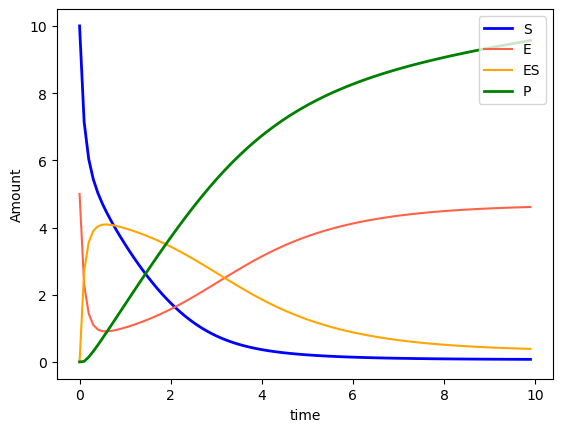

In [42]:
from scipy.integrate import odeint
import numpy as np
import matplotlib.pyplot as plt

# Parameters
# k1, km1, k2, a_s, a_p, b_s, b_p
parameters = [1, 0.4, 0.6, 0.2, 0.1, 0.01, 0.1]

# Initial conditions
# S_init, E_init, ES_init, P_init
variables_init = [10, 5, 0, 0]

# Time range
t_start, t_stop = 0, 10
time_step       = 0.1
time = np.arange(t_start, t_stop, time_step)

# Simulation
variables = odeint(enzyme_kinetic_model_open, variables_init, time, args=(parameters,))

# Plot
plt.plot( time, variables[:,0], c='blue', label='S', linewidth=2)
plt.plot( time, variables[:,1], c='tomato', label='E' )
plt.plot( time, variables[:,2], c='orange', label='ES' )
plt.plot( time, variables[:,3], c='green', label='P', linewidth=2 )

plt.legend(loc='upper right')
plt.xlabel('time')
plt.ylabel('Amount')

plt.show()

#plt.savefig('enzyme_reaction_time_series.png') # plot a png


The reaction ends with finite amount of substrate as the conversion of substrate to product is no longer complete. Also there is a balanced ratio of the $E$ and $ES$ concentrations. Because the reactions are now fully reversible, the final state of the simulation could be called *(bio)chemical equilibrium* but this is not the same as a thermodynamic equilibrium in a closed systme. As such, the final readout is referred to as the open-flow *steady state concentrations* of all species. 

In [29]:
# f'Final concentrations: {variables[-1, :]}'

print(f'Steady State concentrations')
print('')
print(f'S_ss: {variables[-1,0].round(2)}, P_ss: {variables[-1,3].round(2)}')
print(f'E_ss: {variables[-1,1].round(2)}, ES_ss: {variables[-1,2].round(2)}')
print('')


Steady State concentrations

S_ss: 1.51, P_ss: 4.53
E_ss: 1.05, ES_ss: 3.95



**Note on the rate constants**

The rate constants used are arbitrary and only for demonstration of the dynamics. In biochemical models these need to come from experiment or from a database. E.g. [BRENDA](https://www.brenda-enzymes.org/) and [SABIO-RK](https://sabiork.h-its.org/ui/search) both contain lots of biochemical and molecular enzyme reaction parameters. 

__DIY: Integrating the system__
 
> i) Work out what each part of the code is doing<br>
> ii) Copy and modify the code to change parameters and initial conditions. Experiment with different parameter combinations to get a feel for the model. Eventually you might try and predict how a change affects the outcome<br>
> iii) What happens when the amount of $E$ in the system is small? I.e. there is only a little amount of enzyme present. What happens when no enzyme is present?<br>



__DIY: Product binds to enzyme__
> 
> Add in a new reaction for the reverse reaction of product with enzyme to form the ES complex $P + E \xrightarrow{k_{-2}} ES$. Assume the rate constant is $k_{-2}=0.5$. The assumption is that the formation of product is also reversible. How does this change the dynamics above?
> 

In [30]:
def enzyme_kinetic_model_2(variables, time, parameters):
    
    S, E, ES, P = variables[0], variables[1], variables[2], variables[3]
    
    k1, km1, k2, km2 = parameters[0], parameters[1], parameters[2], parameters[3]
    
    dS_dt  = - k1*E*S + km1*ES
    dE_dt  = - k1*E*S + km1*ES + k2*ES - km2*E*P
    dES_dt = + k1*E*S - km1*ES - k2*ES + km2*E*P 
    dP_dt  =                   + k2*ES - km2*E*P 
    
    return [dS_dt, dE_dt, dES_dt, dP_dt]


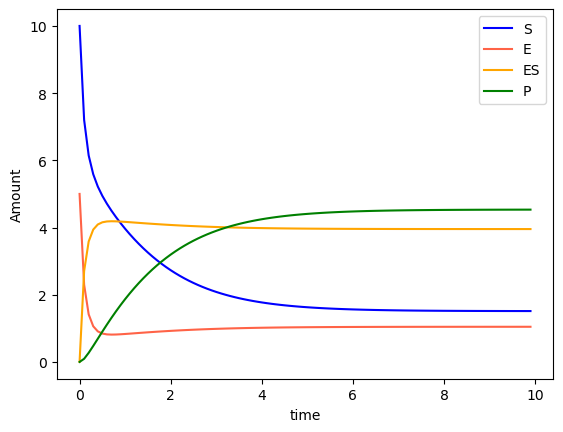

In [31]:
from scipy.integrate import odeint
import numpy as np
import matplotlib.pyplot as plt

# Parameters
# k1, km1, k2, km2
parameters = [1, 0.4, 0.6, 0.5]

# Initial conditions
# S_init, E_init, ES_init, P_init
variables_init = [10, 5, 0, 0]

# Time range
t_start, t_stop = 0, 10
time_step       = 0.1
time = np.arange(t_start, t_stop, time_step)

# Simulation
variables = odeint(enzyme_kinetic_model_2, variables_init, time, args=(parameters,))

# Plot
plt.plot( time, variables[:,0], c='blue', label='S' )
plt.plot( time, variables[:,1], c='tomato', label='E' )
plt.plot( time, variables[:,2], c='orange', label='ES' )
plt.plot( time, variables[:,3], c='green', label='P' )

plt.legend(loc='upper right')
plt.xlabel('time')
plt.ylabel('Amount')

plt.show()

#plt.savefig('enzyme_reaction_time_series.png') # plot a png


In [32]:
print(f'Steady State concentrations')
print('')
print(f'S_ss: {variables[-1,0].round(2)}, P_ss: {variables[-1,3].round(2)}')
print(f'E_ss: {variables[-1,1].round(2)}, ES_ss: {variables[-1,2].round(2)}')
print('')


Steady State concentrations

S_ss: 1.51, P_ss: 4.53
E_ss: 1.05, ES_ss: 3.95



# The Michaelis-Menten model
## Closed Conditions

Now let us simplify the model substantially. We can do that by assuming that this enzymatic reaction obeys the assumptions that go in the Michealis-Menten rate law to describe the conversion of a substrate to product without the need to explicitly consider the enzymatic species. 

Here is the modified reaction scheme for the conversion of substrate to product in the presence of an enzyme:

$$S \xrightarrow{E} P$$

For this reaction, the rate according to Michealis-Menten is 

$$ rate = k_{max} \cdot S /( K_m + S)$$

This rate will be negative for substrate and positive for product. 

Our enzyme reaction model in a closed environment then becomes:


In [34]:
def michaelis_menten_model(variables, time, parameters):
    
    S, P = variables[0], variables[1]
    
    k_max, K_m = parameters[0], parameters[1]
    
    dS_dt  = - k_max*S/(K_m + S)
    dP_dt  =   k_max*S/(K_m + S) 
    
    return [dS_dt, dP_dt]


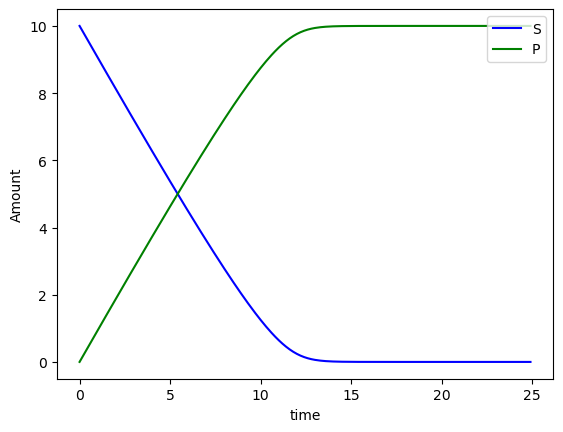

In [35]:
from scipy.integrate import odeint
import numpy as np
import matplotlib.pyplot as plt

# Parameters
# k1, km1, k2, km2
parameters = [1, 0.6]

# Initial conditions
# S_init, E_init, ES_init, P_init
variables_init = [10, 0]

# Time range
t_start, t_stop = 0, 25
time_step       = 0.1
time = np.arange(t_start, t_stop, time_step)

# Simulation
variables = odeint(michaelis_menten_model, variables_init, time, args=(parameters,))

# Plot
plt.plot( time, variables[:,0], c='blue', label='S' )
plt.plot( time, variables[:,1], c='green', label='P' )

plt.legend(loc='upper right')
plt.xlabel('time')
plt.ylabel('Amount')

plt.show()

#plt.savefig('enzyme_reaction_time_series.png') # plot a png


In the closed setting, we have lost some details, but we can recover some decent conversion of substrate to product with only two equations.

## Open-flow Conditions

In living systems, every cell and all tissues are not closed but open systems. They allow exchange of components (like provision of oxygen and removal of carbon dioxide) to maintain a stable condition. This stable condition is no longer the (thermodynamics) equilibrium but a stable condition "far from equilibrium". Referring to the extracellular medium this was labelled *homeostatic* by Claude Bernard. To model this condition we need to add further rates that model the inputs and outputs. Generally this can apply to both subtrate and product. 

Here is the extended model for an enzymatic reaction in an open system:

$$S_{pool} \xrightarrow{a_s} S$$
$$P_{pool} \xrightarrow{a_p} P$$
$$S \xrightarrow{b_s} $$
$$P \xrightarrow{b_p} $$
$$S \xrightarrow{E} P$$

For each species, there is an input or influx and an output or outflux. This contributes for new rates into our model. 

An input is just a constant if we assume the *Pool* concentrations to be constant. 
An output is the product of the species concentration with a rate constant. 

Following this rule we arrive at the following system of two differential equations for our enzyme reaction:

$$ \frac{dS}{dt}  = a_s - b_s \cdot S - k_{max} \cdot S /( K_m + S)$$

$$ \frac{dP}{dt}  = a_p - b_p \cdot P + k_{max} \cdot S /( K_m + S)$$

or a bit simpler:

$$ rate = k_{max} \cdot S /( K_m + S)$$
$$ \frac{dS}{dt}  = a_s - b_s \cdot S - rate$$
$$ \frac{dP}{dt}  = a_p - b_p \cdot P + rate$$

And here is the model implementation and the simulation:

In [36]:
def michaelis_menten_open_model(variables, time, parameters):
    
    S, P = variables[0], variables[1]
    
    k_max, K_m         = parameters[0], parameters[1]
    a_s, a_p, b_s, b_p = parameters[2], parameters[3], parameters[4], parameters[5]

    rate = k_max*S/(K_m + S)
    
    dS_dt  = a_s - b_s*S - rate
    dP_dt  = a_p - b_p*P + rate
    
    return [dS_dt, dP_dt]

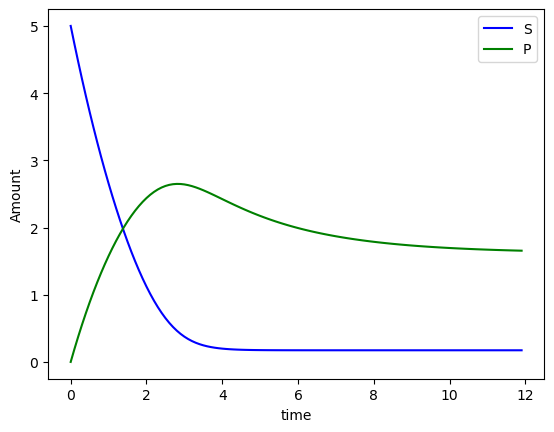


Far-from-equilibrium concentrations:

S_ss: 0.17, P_ss: 1.66



In [37]:
from scipy.integrate import odeint
import numpy as np
import matplotlib.pyplot as plt

# Parameters
# k_max, K_m, a_s, b_s, a_p, b_p
parameters = [2, 0.6, 0.5, 0.2, 0.3, 0.4]

# Initial conditions
# S_init, E_init, ES_init, P_init
variables_init = [5, 0]

# Time range
t_start, t_stop = 0, 12
time_step       = 0.1
time = np.arange(t_start, t_stop, time_step)

# Simulation
variables = odeint(michaelis_menten_open_model, variables_init, time, args=(parameters,))

# Plot
plt.plot( time, variables[:,0], c='blue', label='S' )
plt.plot( time, variables[:,1], c='green', label='P' )

plt.legend(loc='upper right')
plt.xlabel('time')
plt.ylabel('Amount')

plt.show()

print('')
print(f'Far-from-equilibrium concentrations:')
print('')
print(f'S_ss: {variables[-1,0].round(2)}, P_ss: {variables[-1,1].round(2)}')
print('')
#plt.savefig('open_enzyme_reaction_time_series.png') # plot a png


This unremarkable time series has a couple of noteworthy features. Substrate S decreases but ends in a non-zero concentration.  Product P increases and similarly ends in a non-zero concentration. This finite concentrations are reached in the oen system even thought the reaction is irreverible. The reason are the influxes and the outfluxes. You also see that the sum of the S and the P concentration is no longer constant over time as in the previous closed simulation. However, as before, the final state is reached independent of the initial conditions chosen. This time, however its values depend on each of the rate constants. 

The state on the right hand side of the simulation can be called "homeostatic" in the sense that it is robust with respect of external perturbations. After any perturbation is switched off, the final steady-state concentrations will be reached asymptotically. 

This is remarkable as it shows that the control-engineering explanation is not needed for homeostasis: nothing "senses" the current state, nothing measures the deviation from a "desired" state. Nothing pushes the concentrations back to the "desired" state. This was the still widely popular proposal by MIT engineer Walter Cannon. All stability against perturbations comes from the far-from-equilibrium steady state open system. A similar concept was proposed by Harvard biochemist Lawrence Henderson. And while we now know that living systems have many examples of control-engineering types of regulatory circuits implemented, it is not generally needed to maintain stability. The concept of far-from equilibrium steady state brings that feature without additional requirements. This is sometimes referred to as "self-organised". 

There is a readable paper on this historical parallel evolution in an [article in Nature](https://www.semanticscholar.org/paper/The-community-of-the-self-Buchman/3dd2d437f484511f6c8b831771070e1d8bf31816).

# The Hill Reaction with Open Flow

The above Michaelis-Menten reaction can be extended to include a Hill coefficient larger than 1. 

In [38]:
def hill_open_model(variables, time, parameters):
    
    S, P = variables[0], variables[1]
    
    k_max, K_m, n      = parameters[0], parameters[1], parameters[2]
    a_s, a_p, b_s, b_p = parameters[3], parameters[4], parameters[5], parameters[5]

    rate = k_max*S**n/(K_m + S**n)
    
    dS_dt  = a_s - b_s*S - rate
    dP_dt  = a_p - b_p*P + rate
    
    return [dS_dt, dP_dt]


Far-from-equilibrium concentrations:

S_ss: 0.56, P_ss: 1.85



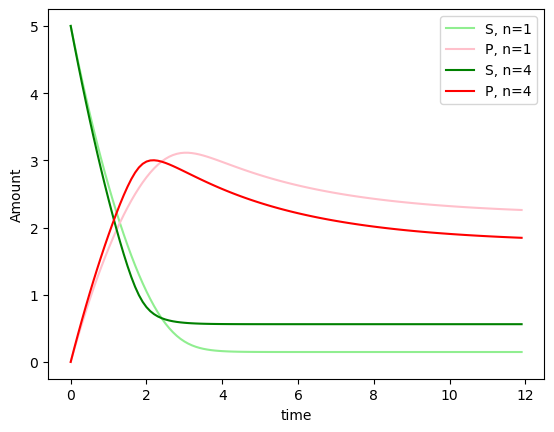

In [39]:
from scipy.integrate import odeint
import numpy as np
import matplotlib.pyplot as plt

n_values = [1, 4]

colors = [('lightgreen', 'green'), ('pink', 'red')]

fig, ax = plt.subplots()

for index, n in enumerate(n_values):

    # Parameters
    # k_max, K_m, n, a_s, b_s, a_p, b_p
    parameters = [2, 0.5, n, 0.5, 0.2, 0.3, 0.4]
    
    # Initial conditions
    # S_init, P_init
    variables_init = [5, 0]
    
    # Time range
    t_start, t_stop = 0, 12
    time_step       = 0.1
    time = np.arange(t_start, t_stop, time_step)
    
    # Simulation
    variables = odeint(hill_open_model, variables_init, time, args=(parameters,))
    
    # Plot
    ax.plot( time, variables[:,0], c=colors[0][index], label=f'S, n={n}' )
    ax.plot( time, variables[:,1], c=colors[1][index], label=f'P, n={n}' )

ax.legend(loc='upper right')
ax.set_xlabel('time')
ax.set_ylabel('Amount')

# fig.show()

print('')
print(f'Far-from-equilibrium concentrations:')
print('')
print(f'S_ss: {variables[-1,0].round(2)}, P_ss: {variables[-1,1].round(2)}')
print('')
#plt.savefig('open_enzyme_reaction_time_series.png') # plot a png


There is a steeper descent near the start of the reaction and the final concentrations differ. The changes are quantitative, not qualitative. 

# History: Prigogine on Far-from-equilibrium Patterns